In [1]:
%run "coli starting run.ipynb"

In [2]:


score_borad = data_create(0,0,0,0)
for i in range(50):
    true_score = i*10+101
    score_borad = pd.concat([score_borad,data_create(50,my_floor(true_score,-2),true_score,0)]).reset_index(drop=True)
    #score_borad = pd.concat([score_borad,data_create(20,my_floor(true_score,-2),true_score,1)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_create(50,my_floor(true_score,-2),true_score,2)]).reset_index(drop=True)



score_borad['int_score'] = score_borad['score']
score_borad['play_time'] = score_borad.apply(lambda x: 0 if x['type']==1 else x['play_time'],axis=1)
#score_borad['score'] = score_borad['score']-100
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score
0,100.0,101,0,0,0,0,0,0,9.0,100.0
1,100.0,101,0,0,0,0,0,0,10.0,100.0
2,100.0,101,0,0,0,0,0,0,12.0,100.0
3,100.0,101,0,0,0,0,0,0,12.0,100.0
4,100.0,101,0,0,0,0,0,0,13.0,100.0
...,...,...,...,...,...,...,...,...,...,...
4995,500.0,591,0,0,0,0,0,2,3.0,500.0
4996,500.0,591,0,0,0,0,0,2,13.0,500.0
4997,500.0,591,0,0,0,0,0,2,8.0,500.0
4998,500.0,591,0,0,0,0,0,2,3.0,500.0


In [3]:
np.random.seed(5)
for i in range(20):
    score_borad = score_borad.sample(frac=1)
    print(i,end="\r", flush=True)
    for id_1 in score_borad.index:
        if score_borad.loc[id_1,'type'] == 2:
            if (i<5):
                score_borad.loc[id_1,'skiped time'] = score_borad.loc[id_1,'skiped time']+1
                continue
        if score_borad.loc[id_1,'att count'] >=score_borad.loc[id_1,'play_time']:
            continue
        pick_list = abs(score_borad['score'] - score_borad.loc[id_1,'score']).drop(id_1).sample(frac=1).sort_values().head(2)
        pick_list = score_borad.loc[pick_list.index]
        id_2 = pick_list[pick_list['true score']==pick_list['true score'].min()].index[0]#np.random.choice(pick_list.index)
        s1,s2 = coli_fight2(score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'],score_borad.loc[id_1,'true score'],score_borad.loc[id_2,'true score'])
        if s1 > score_borad.loc[id_1,'score']:
            score_borad.loc[id_1,'att win'] = score_borad.loc[id_1,'att win']+1
        else:
            score_borad.loc[id_2,'def win'] = score_borad.loc[id_2,'def win']+1
        score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'] = s1,s2
        score_borad.loc[id_1,'att count'],score_borad.loc[id_2,'def count'] = score_borad.loc[id_1,'att count']+1,score_borad.loc[id_2,'def count']+1
score_borad['scorediff'] = score_borad['score'] - score_borad['int_score']
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score,scorediff
3010,460.0,401,0,6,9,2,5,0,6.0,400.0,60.0
4905,500.0,591,0,0,0,0,0,0,0.0,500.0,0.0
4449,550.0,541,0,2,2,2,1,0,2.0,500.0,50.0
4035,540.0,501,0,11,9,6,2,0,11.0,500.0,40.0
4462,560.0,541,5,0,6,0,4,2,0.0,500.0,60.0
...,...,...,...,...,...,...,...,...,...,...,...
3845,490.0,481,0,2,4,2,3,0,2.0,400.0,90.0
1789,200.0,271,5,0,0,0,0,2,0.0,200.0,0.0
2887,430.0,381,5,8,6,6,3,2,8.0,300.0,130.0
3831,490.0,481,0,9,6,7,1,0,9.0,400.0,90.0


<AxesSubplot:xlabel='score', ylabel='true score'>

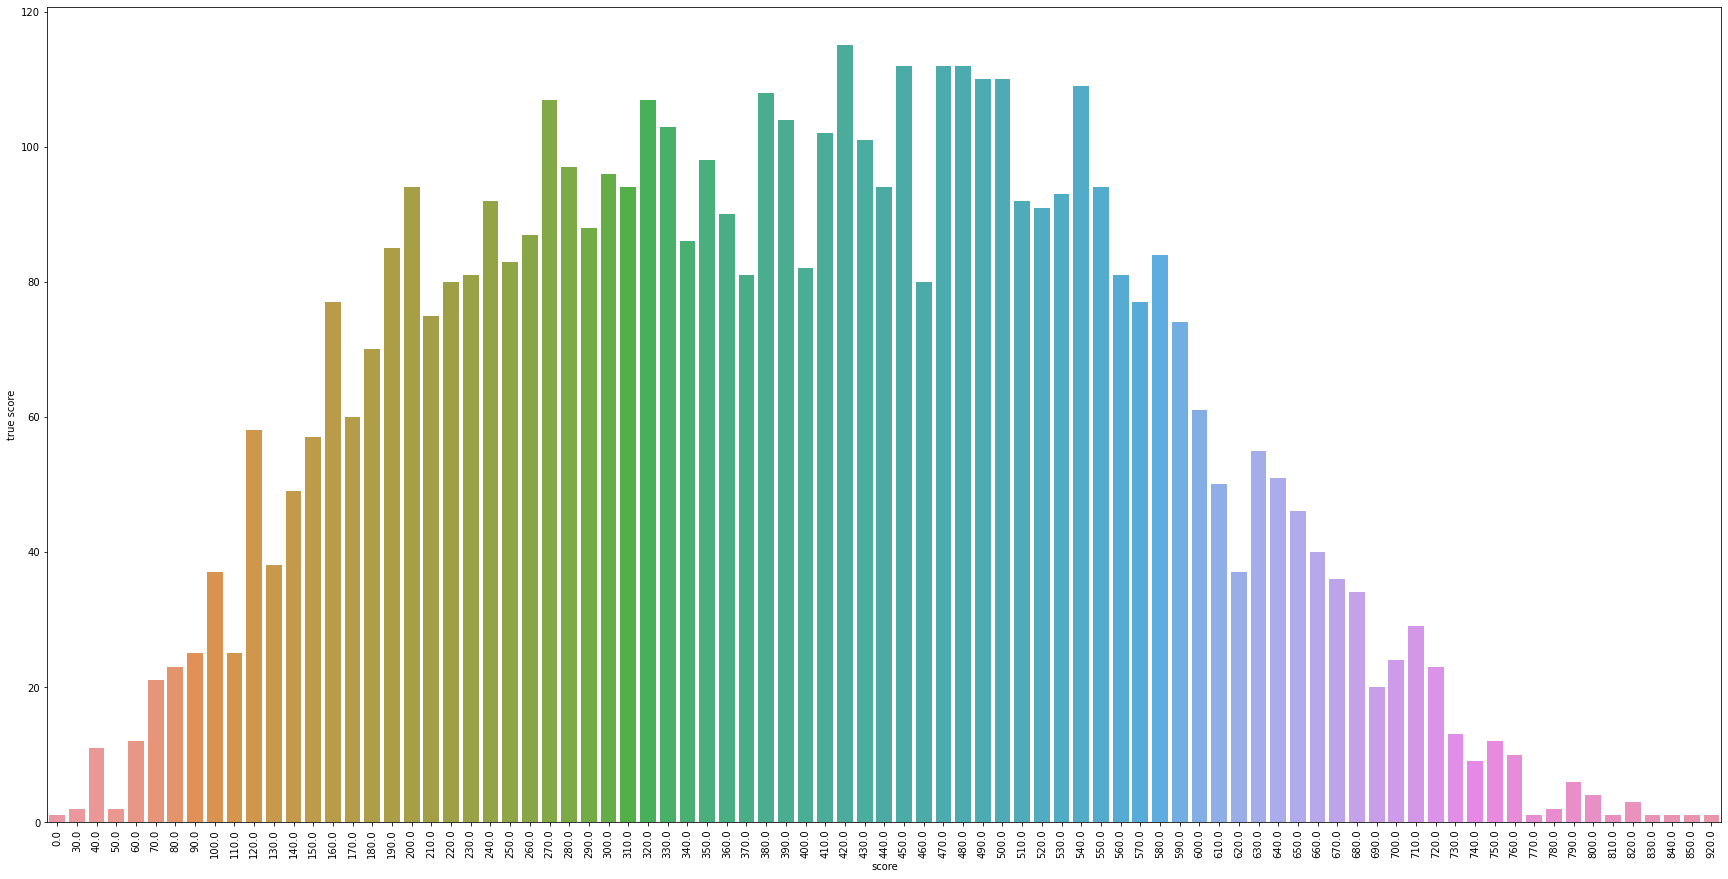

In [4]:
review_df = score_borad.groupby('score')['true score'].count()
fig, ax = plt.subplots(1,figsize=(30, 15),sharey=True)
ax.tick_params(axis='x',labelrotation=90)
sns.barplot(review_df.index,review_df)
#review_df

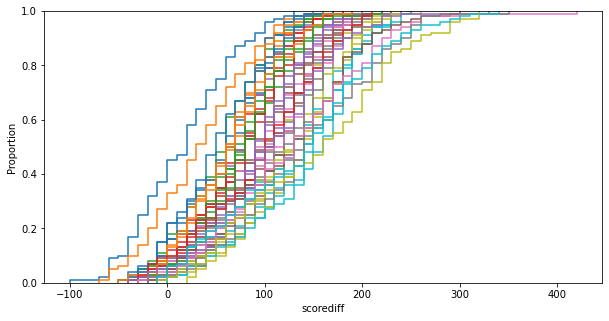

In [5]:


#review_df =score_borad.groupby('scorediff')['true score'].count()/len(score_borad)
kk = score_borad['true score'].unique()
kk.sort()
fig, ax = plt.subplots(1,figsize=(10, 5),sharey=True)
for t_score in kk:
    
    #ax.set_title(str(t_score))
    sns.ecdfplot(data = score_borad[score_borad['true score']==t_score],x="scorediff")
    #fig.show()

In [6]:
score_borad.pivot_table(index ='true score',columns='type' )#.loc[300:399]

att count        att win       def count        def win        \
type               0      2       0     2         0      2       0     2   
true score                                                                 
101            10.64   9.50    5.14  4.86     14.46  14.04    3.80  3.50   
111            10.04   9.38    5.18  5.16     13.28  12.24    3.50  3.38   
121             9.44   9.68    5.18  5.64     12.52  11.26    3.74  3.40   
131             8.80  10.02    4.96  5.98     11.94  10.24    3.78  3.52   
141             8.90   8.02    5.36  4.86      9.96   9.26    3.22  3.46   
151            10.30   8.62    6.20  5.34     10.62   8.26    3.60  3.36   
161             9.94   9.06    6.02  5.98      9.44   7.32    3.26  2.94   
171             9.78   8.06    6.50  5.56      9.16   6.26    3.22  2.80   
181             9.26   7.78    6.22  5.50      7.90   4.30    3.12  2.04   
191            11.00   9.64    7.82  7.36      8.70   4.22    2.96  1.80   
201             9.54   9.74    5.34  5.84     12.24  11.28    3.32  3.46   
211             9.48   9.42    5.08  5.82     11.76  11.50    3.64  3.58   
221            10.16   8.54    5.72  5.46     12.06  10.36    4.08  3.58   
231             9.08   8.32    5.28  5.20     11.24   9.56    3.88  3.58   
241            10.08  10.04    6.32  6.56     11.14   8.84    3.58  3.10   
251             7.80   8.68    5.10  5.76      9.46   8.72    3.16  3.90   
261             8.10   9.50    5.28  6.46      8.62   7.38    2.96  3.04   
271             8.78   8.66    5.94  6.02      8.70   6.62    3.16  2.84   
281            10.70   8.56    7.52  6.46      9.02   5.64    3.18  2.54   
291            10.68  10.78    7.74  8.22      7.24   4.62    2.48  2.00   
301             9.30   9.58    5.22  6.24     11.98  12.32    3.56  3.58   
311            10.76   8.92    6.40  5.50     12.80  11.48    3.28  3.62   
321             8.50  10.10    4.92  6.36     11.18  11.44    3.54  4.00   
331             8.38   8.96    4.96  5.64     11.16  10.00    3.70  3.54   
341             8.54   9.82    5.14  6.46     10.08   9.44    3.42  3.44   
351            11.14  10.58    7.28  7.02     11.36   8.42    3.70  3.16   
361             9.14   8.48    5.90  6.16      8.76   7.50    2.92  2.98   
371             9.68   8.16    6.12  5.88      8.40   6.92    3.68  3.20   
381            11.28   9.58    7.60  7.10      9.28   5.86    3.38  2.70   
391             9.92   7.64    7.14  6.02      7.86   3.26    3.00  1.42   
401            10.64   9.08    5.76  5.58     12.08  11.92    3.50  3.56   
411             8.92   8.64    5.00  5.12     12.26  11.48    3.74  3.86   
421             8.84   8.24    5.06  5.24     11.64  10.78    3.80  3.78   
431             8.16   9.12    4.78  6.02     10.44   9.38    3.52  3.10   
441            10.34  10.00    6.04  6.62     10.50   9.74    3.56  3.72   
451            10.02   9.20    6.66  6.12     10.82   7.58    3.56  3.06   
461            11.54   8.60    7.58  6.00      9.96   7.40    3.14  3.12   
471             9.20   8.72    6.02  6.26      8.08   6.44    3.16  2.74   
481             9.32   8.92    6.42  6.68      9.00   5.66    3.48  2.74   
491            10.32   9.86    7.82  7.58      8.94   3.80    3.10  1.66   
501             7.06   9.54    3.70  5.60     11.46  13.16    3.54  4.36   
511             8.66   9.56    4.84  6.22     10.14  11.50    3.08  3.58   
521            10.02   9.82    5.78  6.20     12.04  11.72    3.74  4.22   
531             9.42  10.08    6.04  6.74     12.18  12.08    3.74  4.52   
541             9.68   9.60    6.22  6.82     11.12  10.02    4.02  3.64   
551            10.28   8.86    6.82  6.26     11.38   8.68    4.42  3.60   
561             9.66   7.76    6.96  5.40      9.72   6.72    4.12  3.42   
571            10.12   9.32    7.16  7.14      7.92   5.96    3.66  2.68   
581             8.54   9.64    6.66  7.82      4.26   3.76    2.18  2.22   
591             8.70   8.38    6.98  7.14      1.66   1.08 

In [7]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[300:399]

att count        att win       def count        def win        \
type               0      2       0     2         0      2       0     2   
true score                                                                 
301             9.30   9.58    5.22  6.24     11.98  12.32    3.56  3.58   
311            10.76   8.92    6.40  5.50     12.80  11.48    3.28  3.62   
321             8.50  10.10    4.92  6.36     11.18  11.44    3.54  4.00   
331             8.38   8.96    4.96  5.64     11.16  10.00    3.70  3.54   
341             8.54   9.82    5.14  6.46     10.08   9.44    3.42  3.44   
351            11.14  10.58    7.28  7.02     11.36   8.42    3.70  3.16   
361             9.14   8.48    5.90  6.16      8.76   7.50    2.92  2.98   
371             9.68   8.16    6.12  5.88      8.40   6.92    3.68  3.20   
381            11.28   9.58    7.60  7.10      9.28   5.86    3.38  2.70   
391             9.92   7.64    7.14  6.02      7.86   3.26    3.00  1.42   

           int_score        play_time         score        scorediff         \
type               0      2         0      2      0      2         0      2   
true score                                                                    
301            300.0  300.0      9.30  10.08  350.6  375.6      50.6   75.6   
311            300.0  300.0     10.76   9.42  354.8  369.6      54.8   69.6   
321            300.0  300.0      8.50  10.64  357.0  395.4      57.0   95.4   
331            300.0  300.0      8.38   9.64  364.4  385.8      64.4   85.8   
341            300.0  300.0      8.54  10.40  370.6  404.4      70.6  104.4   
351            300.0  300.0     11.14  11.26  404.4  415.4     104.4  115.4   
361            300.0  300.0      9.14   8.88  385.6  414.4      85.6  114.4   
371            300.0  300.0      9.68   8.46  413.2  421.6     113.2  121.6   
381            300.0  300.0     11.28  10.06  423.8  439.6     123.8  139.6   
391            300.0  300.0      9.92   7.90  426.4  414.2     126.4  114.2   

           skiped time     
type                 0  2  
true score                 
301                  0  5  
311                  0  5  
321                  0  5  
331                  0  5  
341                  0  5  
351                  0  5  
361                  0  5  
371                  0  5  
381                  0  5  
391                  0  5

In [8]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[300:399][['att count','def count','scorediff']]

att count        def count        scorediff       
type               0      2         0      2         0      2
true score                                                   
301             9.30   9.58     11.98  12.32      50.6   75.6
311            10.76   8.92     12.80  11.48      54.8   69.6
321             8.50  10.10     11.18  11.44      57.0   95.4
331             8.38   8.96     11.16  10.00      64.4   85.8
341             8.54   9.82     10.08   9.44      70.6  104.4
351            11.14  10.58     11.36   8.42     104.4  115.4
361             9.14   8.48      8.76   7.50      85.6  114.4
371             9.68   8.16      8.40   6.92     113.2  121.6
381            11.28   9.58      9.28   5.86     123.8  139.6
391             9.92   7.64      7.86   3.26     126.4  114.2